In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
titanic_df = pd.read_csv('/content/drive/MyDrive/data file/titanic-data.csv')

In [4]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# renaming columns

#Pclass =Pstatus
#Sex=Gender

In [6]:
titanic_df.rename(columns={'Pclass':'Pstatus','Sex':'Gender'},inplace=True)

In [7]:
titanic_df.head()

,PassengerId,Survived,Pstatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
#handling incorrect data
import numpy as np

data = pd.DataFrame({
    "id":[1,3,5,7,9],
    "name":["John","Jane","Jennifer","Johan","Jeff"],
    "age":[25,-32,19,43,55],
    "gender":["M","M","Z","F","F"],
    "income":[400,700,300,np.nan,600]
})

In [9]:
data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,-32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,43,F,NaN
4,9,Jeff,55,F,600.0


In [10]:
data.dtypes

,0
id,int64
name,object
age,int64
gender,object
income,float64


In [11]:
data["age"] = data["age"].abs()

In [12]:
data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,43,F,NaN
4,9,Jeff,55,F,600.0


In [13]:
#class task
#set the boundary remove less than 18, above 45

In [14]:
#boundary
filter_age = data[(data["age"]>=18) & (data["age"]<=45)]
filter_age

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,43,F,NaN


In [15]:
data[data.gender.isin(["M","F"])]

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
3,7,Johan,43,F,NaN
4,9,Jeff,55,F,600.0


In [16]:
# isin() to filter to the DataFrame

In [17]:
data[data.name.isin(["John"])]

,id,name,age,gender,income
0,1,John,25,M,400.0


In [18]:
#saving a dataframe

data.to_csv("clean_data.csv",index=False)

In [19]:
data.to_json("clean_data.json",index=False,orient="records")

In [20]:
import pandas as pd

data = {
    "Gender": ["Male", "Male", "Male", "Female", "Female", "Female",
               "Male", "Female", "Male", "Female"],
    "Purchased": ["Yes", "No", "Yes", "No", "Yes", "No",
                  "Yes", "No", "Yes", "Yes"]
}

df = pd.DataFrame(data)

print(df)

   Gender Purchased
0    Male       Yes
1    Male        No
2    Male       Yes
3  Female        No
4  Female       Yes
5  Female        No
6    Male       Yes
7  Female        No
8    Male       Yes
9  Female       Yes


In [21]:
contingency_table = pd.crosstab(df["Gender"], df["Purchased"])
contingency_table

Purchased,No,Yes
Gender,,
Female,3,2
Male,1,4


In [22]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-squared statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-squared statistic: 0.41666666666666663
P-value: 0.5186050164287255
Degrees of freedom: 1
Expected frequencies:
 [[2. 3.]
 [2. 3.]]


In [23]:
alpha = 0.05

if p < alpha:
    print("Reject the null hypothesis. There is a significant association between gender and purchase.")
else:
    print("Fail to reject the null hypothesis. There is no significant association between gender and purchase.")

Fail to reject the null hypothesis. There is no significant association between gender and purchase.


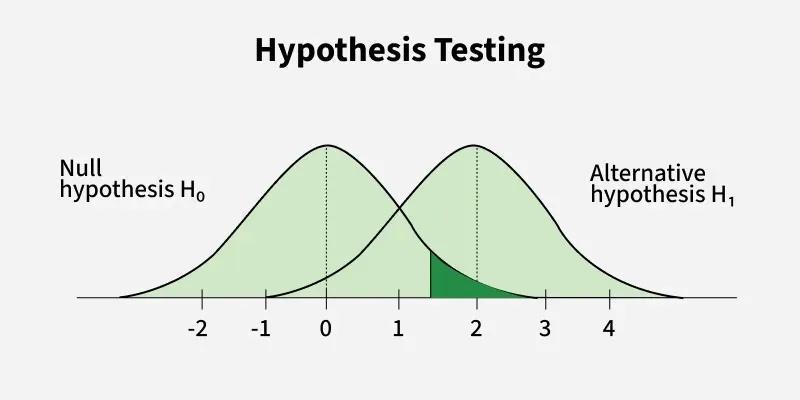

In [24]:
#degree of freedom = (rows -1) * (columns -1)

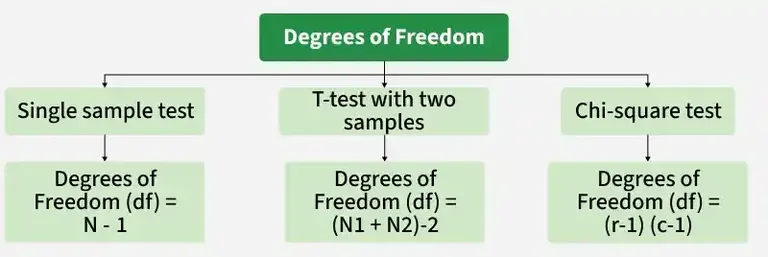

Listwise deletion

pairwise deletion

dropping variables

single imputation = hot/cold imputation, mean median , mode, last observed value, linear interpolation,

Multiple Imputaion = MICE algorithm